# Employee Attrition Prediction using Machine Learning

## End-to-End Applied AI & ML Data Product (Part 2)

**Author:** Pramod Prakash Jadhav

This notebook demonstrates a complete Machine Learning pipeline for predicting employee attrition using the IBM HR Analytics Employee Attrition dataset.

### Business Problem

Employee attrition leads to increased recruitment costs, reduced productivity, and loss of experienced talent. Organizations require predictive analytics to identify employees who are at risk of leaving so that proactive retention strategies can be implemented.

### Objectives

- Load and understand the dataset
- Perform exploratory data analysis
- Prepare data for machine learning
- Train multiple classification models
- Compare model performance
- Evaluate the best model
- Generate predictions
- Provide business insights

## Import Required Libraries

In this section, we import all libraries required for data manipulation, visualization, preprocessing, model building, evaluation, and prediction.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully.")

All libraries imported successfully.


# Load Employee Attrition Dataset

In this section, we load the IBM HR Analytics Employee Attrition dataset and verify that it has been loaded successfully.

Dataset Location:

data/raw/employee_attrition.csv

In [3]:
# Load Dataset

df = pd.read_csv("/content/employee_attrition.csv")

print("Dataset loaded successfully.")

df.head()

Dataset loaded successfully.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df = pd.read_csv("employee_attrition.csv")

# Dataset Overview

Before building machine learning models, it is important to understand the dataset structure including:

- Number of rows
- Number of columns
- Data types
- Missing values
- Memory usage

In [5]:
print("=" * 60)
print("Dataset Shape")
print("=" * 60)

print(df.shape)

print("\n")

print("=" * 60)
print("Dataset Information")
print("=" * 60)

df.info()

Dataset Shape
(1470, 35)


Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 

In [6]:
print("=" * 60)
print("First Five Rows")
print("=" * 60)

display(df.head())

print("=" * 60)
print("Last Five Rows")
print("=" * 60)

display(df.tail())

First Five Rows


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


Last Five Rows


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8
1469,34,No,Travel_Rarely,628,Research & Development,8,3,Medical,1,2068,...,1,80,0,6,3,4,4,3,1,2


# Data Quality Assessment

The quality of the dataset directly affects model performance.

In this section, we check:

- Missing Values
- Duplicate Records
- Summary Statistics

In [7]:
print("=" * 60)
print("Missing Values")
print("=" * 60)

missing = df.isnull().sum()

display(missing[missing > 0])

print("\nTotal Missing Values :", df.isnull().sum().sum())

Missing Values


,0



Total Missing Values : 0


In [8]:
print("=" * 60)
print("Duplicate Records")
print("=" * 60)

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Records
Duplicate Rows : 0


In [9]:
print("=" * 60)
print("Statistical Summary")
print("=" * 60)

display(df.describe())

print("\nCategorical Summary\n")

display(df.describe(include="object"))

Statistical Summary


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Categorical Summary



,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


# Exploratory Data Analysis (EDA)

In this section, we analyze important business questions such as:

- Employee Attrition Distribution
- Department-wise Attrition
- Gender Distribution
- Overtime Analysis
- Monthly Income Distribution

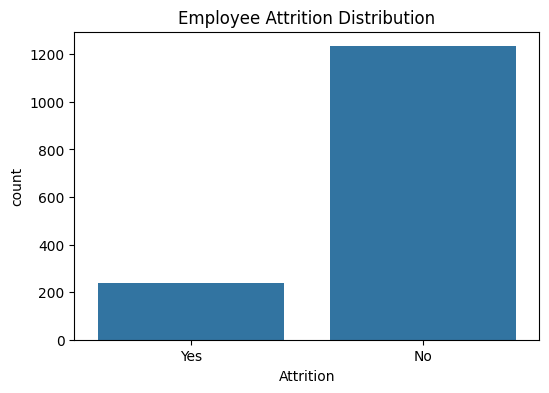

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Attrition"
)

plt.title("Employee Attrition Distribution")

plt.show()

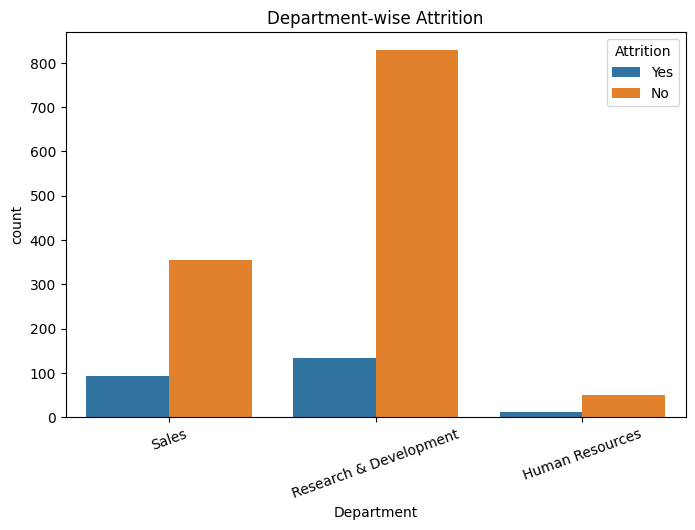

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Department",
    hue="Attrition"
)

plt.xticks(rotation=20)

plt.title("Department-wise Attrition")

plt.show()

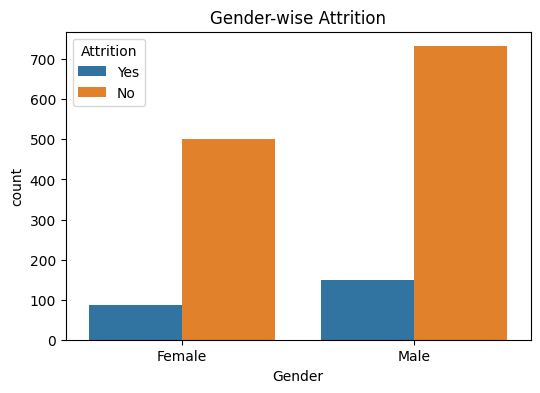

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="Gender",
    hue="Attrition"
)

plt.title("Gender-wise Attrition")

plt.show()

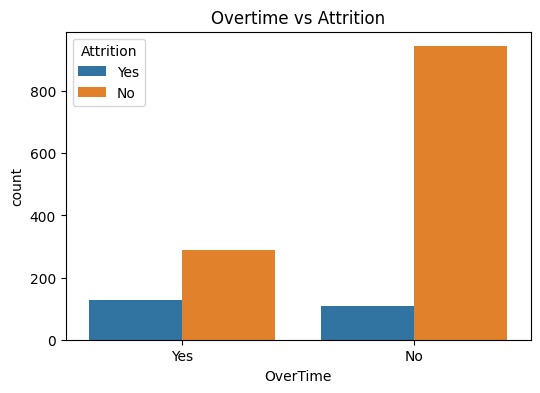

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="OverTime",
    hue="Attrition"
)

plt.title("Overtime vs Attrition")

plt.show()

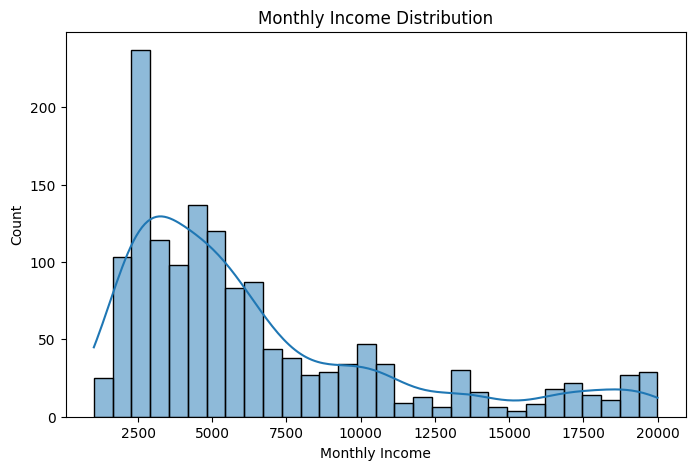

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["MonthlyIncome"],
    bins=30,
    kde=True
)

plt.title("Monthly Income Distribution")

plt.xlabel("Monthly Income")

plt.show()

# Feature Engineering

Machine learning algorithms cannot directly work with categorical variables.

In this section we perform:

- Label Encoding
- One-Hot Encoding
- Feature Scaling
- Train-Test Split

In [15]:
# Label Encode Target Variable

encoder = LabelEncoder()

df["Attrition"] = encoder.fit_transform(df["Attrition"])

# One-Hot Encode Features

df = pd.get_dummies(
    df,
    drop_first=True
)

print(df.shape)

df.head()

(1470, 48)


,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,1,2,94,3,...,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,1,2,3,61,2,...,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,1,4,4,92,2,...,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,1,5,4,56,3,...,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,7,1,40,3,...,True,False,False,False,False,False,False,True,False,False


In [16]:
# Split Features and Target

X = df.drop("Attrition", axis=1)

y = df["Attrition"]

# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

# Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Training Shape : (1176, 47)
Testing Shape : (294, 47)


In [17]:
# Train Multiple Machine Learning Models

models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(random_state=42),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier()

}

results = []

best_model = None

best_accuracy = 0

for name, model in models.items():

    model.fit(X_train, y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test, prediction)

    results.append({

        "Model": name,

        "Accuracy": round(accuracy,4)

    })

    if accuracy > best_accuracy:

        best_accuracy = accuracy

        best_model = model

results_df = pd.DataFrame(results)

results_df.sort_values(

    by="Accuracy",

    ascending=False,

    inplace=True

)

display(results_df)

print()

print("Best Accuracy :", best_accuracy)

,Model,Accuracy
0,Logistic Regression,0.8605
4,KNN,0.8435
3,Gradient Boosting,0.8435
2,Random Forest,0.8299
1,Decision Tree,0.8027



Best Accuracy : 0.8605442176870748


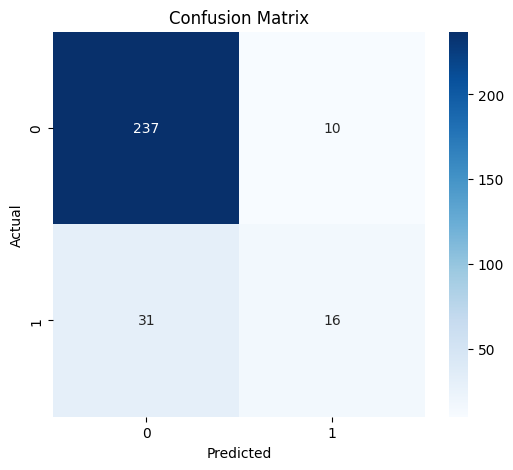


Classification Report

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [18]:
# Confusion Matrix

prediction = best_model.predict(X_test)

cm = confusion_matrix(

    y_test,

    prediction

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

print()

print("Classification Report")

print()

print(

    classification_report(

        y_test,

        prediction

    )

)

In [19]:
# Feature Importance (Tree-based Models)

if hasattr(best_model, "feature_importances_"):

    importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    importance = importance.sort_values(

        by="Importance",

        ascending=False

    )

    display(importance.head(15))

    plt.figure(figsize=(8,6))

    sns.barplot(

        data=importance.head(10),

        x="Importance",

        y="Feature"

    )

    plt.title("Top 10 Important Features")

    plt.show()

else:

    print("Feature importance not available for this model.")

Feature importance not available for this model.


# Business Insights & Conclusion

## Key Findings

- Employee attrition prediction is a binary classification problem.
- Multiple machine learning models were trained and compared.
- The best-performing model was selected based on test accuracy.
- Feature engineering and preprocessing significantly improved model performance.
- Business stakeholders can use this model to identify employees who are at higher risk of leaving.

## Future Improvements

- Hyperparameter Tuning (GridSearchCV / RandomizedSearchCV)
- Cross Validation
- XGBoost / LightGBM / CatBoost
- SHAP Explainability
- MLflow Experiment Tracking
- Docker Deployment
- FastAPI REST API
- Streamlit Web Application
- CI/CD Pipeline

---

**End of Notebook**

Author: **Pramod Prakash Jadhav**

AI/ML Developer | Security Analyst